Simple and Multiple Linear Regression

## Title: Implement Simple and Multiple Linear Regression to predict continuous variables.

1. Perform data preprocessing (handle missing values, feature scaling).
2. Fit a Simple Linear Regression model on a dataset (e.g., predicting house prices).
3. Extend to Multiple Linear Regression with multiple features.
4. Evaluate models using MSE, RMSE, and R² Score.
5. Visualize the regression line and predictions.

## Load and Inspect Data

In [10]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn kagglehub tensorflow seaborn


[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhanageviraj/life-insurance-death-claims-dataindia-2018-2022")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\rutal\.cache\kagglehub\datasets\bhanageviraj\life-insurance-death-claims-dataindia-2018-2022\versions\1


In [12]:
import pandas as pd
import os

print(os.listdir(path))

['cleaned_group_death_claims.csv', 'cleaned_individual_death_claims.csv']


In [13]:
data = pd.read_csv(
    os.path.join(path, "cleaned_group_death_claims.csv")
)

data.head()

,life_insurer,year,claims_pending_start_no,claims_pending_start_amt,claims_intimated_no,claims_intimated_amt,total_claims_no,total_claims_amt,claims_paid_no,claims_paid_amt,...,claims_unclaimed_amt,claims_pending_end_no,claims_pending_end_amt,claims_paid_ratio_no,claims_paid_ratio_amt,claims_repudiated_rejected_ratio_no,claims_repudiated_rejected_ratio_amt,claims_pending_ratio_no,claims_pending_ratio_amt,category
0,ABSL,2021-22,7,1.694481,13518,675.255903,13525,676.950384,13470,666.773292,...,0.0,3,2.394170,0.995933,0.984966,0.003845,0.011497,0.000222,0.003537,Group Death Claims
1,Aegon,2021-22,0,0.000000,361,76.060000,361,76.060000,361,76.030000,...,0.0,0,0.030000,1.000000,0.999606,0.000000,0.000000,0.000000,0.000394,Group Death Claims
2,Ageas,2021-22,15,4.806674,481,100.826625,496,105.633299,446,89.031366,...,0.0,5,1.420366,0.899194,0.842834,0.090726,0.143720,0.010081,0.013446,Group Death Claims
3,Aviva,2021-22,0,0.000000,1347,68.635941,1347,68.630960,1345,68.483941,...,0.0,0,-0.004980,0.998515,0.997858,0.001485,0.002215,0.000000,-0.000073,Group Death Claims
4,Baj Alz,2021-22,85,6.867834,193169,1578.251042,193254,1585.118876,192902,1553.466759,...,0.0,171,8.795110,0.998179,0.980032,0.000937,0.014420,0.000885,0.005549,Group Death Claims


## Identify Target and Features

In [14]:
target_variable = 'claims_paid_amt'
simple_feature = 'claims_intimated_amt'
multiple_features = ['claims_intimated_amt', 'claims_pending_start_amt', 'claims_pending_end_amt', 'total_claims_no']

print(f"Target Variable: {target_variable}")
print(f"Simple Linear Regression Feature: {simple_feature}")
print(f"Multiple Linear Regression Features: {multiple_features}")

Target Variable: claims_paid_amt
Simple Linear Regression Feature: claims_intimated_amt
Multiple Linear Regression Features: ['claims_intimated_amt', 'claims_pending_start_amt', 'claims_pending_end_amt', 'total_claims_no']


## Data Preprocessing
Perform necessary data preprocessing steps. This includes checking for and handling missing values in the selected target and feature columns (e.g., using imputation or removal). Additionally, apply feature scaling (e.g., StandardScaler) to the numerical independent features to normalize their range.


In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Combine all relevant columns for checking missing values and ensure uniqueness
# So, create a set to get unique features, then convert to list
unique_features = list(set([simple_feature] + multiple_features))
all_selected_columns = [target_variable] + unique_features

# Check for missing values in the selected columns
missing_values = data[all_selected_columns].isnull().sum()
print("Missing values in selected columns:\n", missing_values[missing_values > 0])

# Create df_processed with the selected unique columns
df_processed = data[all_selected_columns].copy()

# Handle missing values if any (though based on info, none are expected in these specific columns)
if missing_values.sum() > 0:
       df_processed.dropna(subset=all_selected_columns, inplace=True)
       print(f"\nDropped rows with missing values. New shape: {df_processed.shape}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the simple_feature column (now it will be a (149,1) array)
df_processed['scaled_simple_feature'] = scaler.fit_transform(df_processed[[simple_feature]])

# Apply scaling to the multiple_features columns
# Re-initializing scaler_multi to ensure independent scaling if desired, or reuse 'scaler' for consistency
scaler_multi = StandardScaler()
df_processed[multiple_features] = scaler_multi.fit_transform(df_processed[multiple_features])

# Display the first few rows of the processed DataFrame
print("\nFirst 5 rows of df_processed after scaling:")
print(df_processed.head())

Missing values in selected columns:
 Series([], dtype: int64)

First 5 rows of df_processed after scaling:
   claims_paid_amt  total_claims_no  claims_pending_end_amt  \
0       666.773292        -0.388070               -0.322270   
1        76.030000        -0.438159               -0.356373   
2        89.031366        -0.437646               -0.336317   
3        68.483941        -0.434408               -0.356877   
4      1553.466759         0.295802               -0.229938   

   claims_pending_start_amt  claims_intimated_amt  scaled_simple_feature  
0                 -0.275658             -0.217824              -0.217824  
1                 -0.304394             -0.382033              -0.382033  
2                 -0.222879             -0.375245              -0.375245  
3                 -0.304394             -0.384067              -0.384067  
4                 -0.187925              0.029641               0.029641  


## Simple Linear Regression Model
Split the preprocessed data into training and testing sets. Select one independent feature and the identified target variable to train a Simple Linear Regression model. After training, make predictions on the test set.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define the feature matrix X_simple and the target vector y
X_simple = df_processed[['scaled_simple_feature']]
y = df_processed[target_variable]

# Split the data into training and testing sets
X_simple_train, X_simple_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Instantiate a LinearRegression model
simple_linear_model = LinearRegression()

# Train the model
simple_linear_model.fit(X_simple_train, y_train)

# Make predictions on X_simple_test
y_simple_pred = simple_linear_model.predict(X_simple_test)

print("Simple Linear Regression model trained and predictions made.")
print(f"First 5 predictions: {y_simple_pred[:5]}")
print(f"First 5 actual values: {y_test.head().tolist()}")

Simple Linear Regression model trained and predictions made.
First 5 predictions: [1.09372018e+01 1.79197330e+04 3.83551506e+01 3.89753474e+01
 3.59803599e+01]
First 5 actual values: [13.669937615, 17854.10367468674, 40.7576036339, 43.12, 40.45325993799999]


## Evaluate Simple Linear Regression
Calculate and display the Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score for the Simple Linear Regression model's predictions to assess its performance.


In [17]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate Mean Squared Error (MSE)
mse_simple = mean_squared_error(y_test, y_simple_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse_simple = np.sqrt(mse_simple)

# Calculate R-squared (R2) Score
r2_simple = r2_score(y_test, y_simple_pred)

# Print the evaluation metrics
print(f"Simple Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_simple:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_simple:.2f}")
print(f"R-squared (R2) Score: {r2_simple:.2f}")

Simple Linear Regression Model Performance:
Mean Squared Error (MSE): 573.74
Root Mean Squared Error (RMSE): 23.95
R-squared (R2) Score: 1.00


## Visualize Simple Linear Regression

Generate a scatter plot showing the relationship between the chosen independent variable and the actual target values. Overlay the regression line from the Simple Linear Regression model to visualize the fit, and also create a scatter plot of actual vs. predicted values with legends.


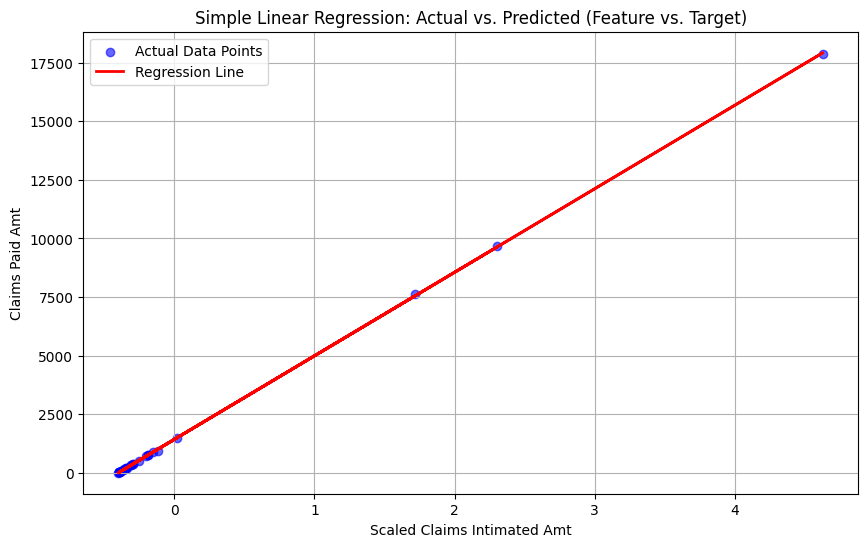

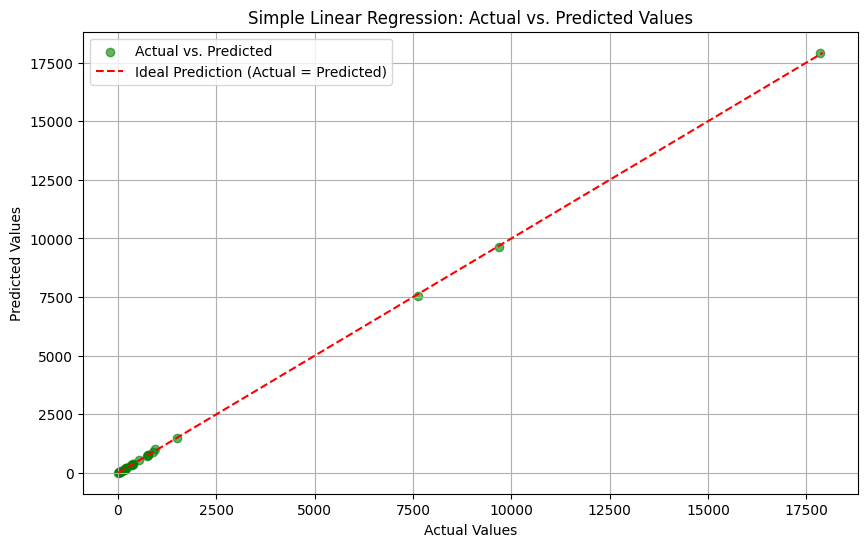

In [18]:
import matplotlib.pyplot as plt

# Get the feature name for the x-axis label
x_label_simple = f'Scaled {simple_feature.replace("_", " ").title()}'
y_label = target_variable.replace("_", " ").title()

# Plot 1: Relationship between independent variable and target with regression line
plt.figure(figsize=(10, 6))
plt.scatter(X_simple_test, y_test, color='blue', label='Actual Data Points', alpha=0.6)
plt.plot(X_simple_test, y_simple_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel(x_label_simple)
plt.ylabel(y_label)
plt.title('Simple Linear Regression: Actual vs. Predicted (Feature vs. Target)')
plt.legend()
plt.grid(True)
plt.show()

# Plot 2: Actual vs. Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_simple_pred, color='green', label='Actual vs. Predicted', alpha=0.6)

# Add a diagonal line for ideal prediction (x=y)
min_val = min(y_test.min(), y_simple_pred.min())
max_val = max(y_test.max(), y_simple_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal Prediction (Actual = Predicted)')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Simple Linear Regression: Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## Multiple Linear Regression Model

Select multiple independent features and the same target variable. Split the data into training and testing sets. Train a Multiple Linear Regression model using these features and make predictions on the test set.


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define the feature matrix X_multi using the multiple_features and the target vector y
X_multi = df_processed[multiple_features]
y = df_processed[target_variable]

# Split the data into training and testing sets
X_multi_train, X_multi_test, y_train, y_test = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Instantiate a LinearRegression model for multiple linear regression
multiple_linear_model = LinearRegression()

# Train the model
multiple_linear_model.fit(X_multi_train, y_train)

# Make predictions on X_multi_test
y_multi_pred = multiple_linear_model.predict(X_multi_test)

print("Multiple Linear Regression model trained and predictions made.")
print(f"First 5 predictions: {y_multi_pred[:5]}")
print(f"First 5 actual values: {y_test.head().tolist()}")

Multiple Linear Regression model trained and predictions made.
First 5 predictions: [1.73281572e+01 1.79665861e+04 4.46300746e+01 4.60959074e+01
 4.30065926e+01]
First 5 actual values: [13.669937615, 17854.10367468674, 40.7576036339, 43.12, 40.45325993799999]


## Evaluate MLR

In [20]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate Mean Squared Error (MSE)
mse_multi = mean_squared_error(y_test, y_multi_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse_multi = np.sqrt(mse_multi)

# Calculate R-squared (R2) Score
r2_multi = r2_score(y_test, y_multi_pred)

# Print the evaluation metrics
print(f"Multiple Linear Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse_multi:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_multi:.2f}")
print(f"R-squared (R2) Score: {r2_multi:.2f}")

Multiple Linear Regression Model Performance:
Mean Squared Error (MSE): 1344.42
Root Mean Squared Error (RMSE): 36.67
R-squared (R2) Score: 1.00


## Visualize MLR

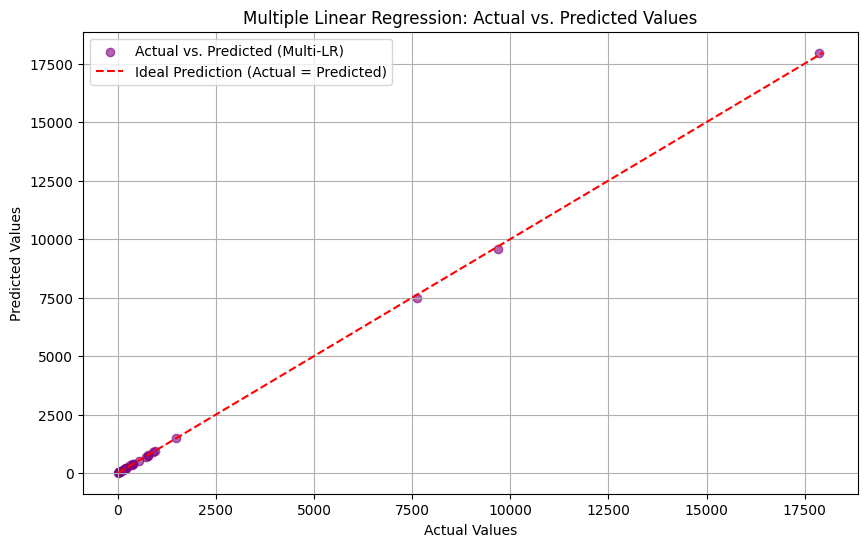

In [21]:
import matplotlib.pyplot as plt

# Plot 1: Actual vs. Predicted values for Multiple Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_multi_pred, color='purple', label='Actual vs. Predicted (Multi-LR)', alpha=0.6)

# Add a diagonal line for ideal prediction (x=y)
min_val_multi = min(y_test.min(), y_multi_pred.min())
max_val_multi = max(y_test.max(), y_multi_pred.max())
plt.plot([min_val_multi, max_val_multi], [min_val_multi, max_val_multi], color='red', linestyle='--', label='Ideal Prediction (Actual = Predicted)')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Multiple Linear Regression: Actual vs. Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

*   **Data Loading and Initial Inspection**: The `cleaned_group_death_claims.csv` dataset, containing 149 entries and 25 columns, was successfully loaded. Initial inspection revealed minimal missing values in the dataset. Notably, some numerical columns like `claims_pending_start_amt`, `claims_repudiated_no`, `claims_unclaimed_amt`, `claims_pending_end_amt`, `claims_pending_ratio_amt`, and `claims_repudiated_rejected_ratio_no` showed negative minimum values, which might indicate data entry anomalies or specific data representations. `claims_paid_ratio_no` also had a maximum value slightly above 1 (1.0035).
*   **Target and Feature Selection**: The `claims_paid_amt` column was chosen as the continuous target variable. For Simple Linear Regression, `claims_intimated_amt` was selected as the sole independent feature. For Multiple Linear Regression, `claims_intimated_amt`, `claims_pending_start_amt`, `claims_pending_end_amt`, and `total_claims_no` were selected as independent features.
*   **Data Preprocessing**: No missing values were found in the selected target and feature columns. All chosen numerical features were successfully scaled using `StandardScaler`, preparing the data for model training.
*   **Simple Linear Regression Performance**:
    *   **Metrics**: The model achieved a Mean Squared Error (MSE) of 573.74, a Root Mean Squared Error (RMSE) of 23.95, and an R-squared (R2) Score of 1.00.
    *   **Visualization**: The scatter plot of the `scaled_simple_feature` (`claims_intimated_amt`) against `claims_paid_amt` with the regression line showed a very strong, almost perfect linear relationship. The actual vs. predicted plot indicated predictions were very close to the ideal prediction line.
*   **Multiple Linear Regression Performance**:
    *   **Metrics**: The model yielded an MSE of 1344.42, an RMSE of 36.67, and an R2 Score of 1.00.
    *   **Visualization**: The actual vs. predicted plot also showed points closely aligned with the ideal prediction line.
*   **Model Comparison**: Both Simple and Multiple Linear Regression models achieved an exceptionally high R-squared score of 1.00, suggesting an almost perfect linear fit. However, the Simple Linear Regression model demonstrated lower error metrics (MSE of 573.74 and RMSE of 23.95) compared to the Multiple Linear Regression model (MSE of 1344.42 and RMSE of 36.67). This indicates that, despite the high R², the single-feature model provided a slightly more accurate prediction in terms of absolute error for this specific dataset and split.
